<h1><b>Door Movement Data Preprocessing</b></h1>

<h4><b>Background Information</b></h4>

The Door subsystem in NEBULA X Problem Statement 3 records one train door controller as a continuous
50 Hz log. Each opening or closing movement must be located in the stream and labelled `Normal` or
`Abnormal resistance`, and submissions are scored by IoU-weighted F1 over the predicted segments. The
Door exploratory data analysis established that pauses in logging separate consecutive movements.

<h4><b>Objective</b></h4>

This notebook converts the raw Train and Test streams into validated, model-ready tables. It segments
both streams into movements, verifies the segmentation against the Train answer file, attaches labels,
flags unreliable values, builds per-movement representations, assigns fixed validation folds, and
saves every output for later model training. No model is trained and no Test label is inferred.

<h4><b>Project Workflow</b></h4>

The workflow configures the environment, inventories and loads the files, and validates schema, missing
values, duplicates, timestamps and value domains. It then segments the streams, joins the answer labels,
derives quality flags, constructs profiles, window and phase statistics and position-binned current,
assigns stratified and time-ordered folds, and exports the results with a manifest.

<h4><b>Dataset Used</b></h4>

`PS3/02_Datasets/Door` contains `Train.csv`, `Test.csv` and `Train_Segments_Answer.csv`. The streams
share 17 columns: a native timestamp such as `2023-7-5-0-0-3-700`, motor current, voltage and back
electromotive force, controller timing values, open and close commands, door switches, status flags and
door leaf position. The answer file lists each labelled Train movement with its bounds, operation,
status and row count. Outputs are written to `data/processed/door`, which is excluded from version
control.

<h4><b>Table of Contents</b></h4>
<ul>
  <li><a href="#section-1">Section 1: Environment Setup and Configuration</a>
    <ul>
      <li><a href="#1-1">1.1 Libraries and Display Settings</a></li>
      <li><a href="#1-2">1.2 Dataset Location and Output Directory</a></li>
      <li><a href="#1-3">1.3 Environment Versions</a></li>
    </ul>
  </li>
  <li><a href="#section-2">Section 2: Data Loading and Inventory</a>
    <ul>
      <li><a href="#2-1">2.1 File Inventory</a></li>
      <li><a href="#2-2">2.2 Stream and Answer Loading</a></li>
    </ul>
  </li>
  <li><a href="#section-3">Section 3: Data Inspection and Validation</a>
    <ul>
      <li><a href="#3-1">3.1 Columns, Roles and Data Types</a></li>
      <li><a href="#3-2">3.2 Missing Values and Duplicates</a></li>
      <li><a href="#3-3">3.3 Timestamp Parsing</a></li>
      <li><a href="#3-4">3.4 Sampling Steps and Ordering</a></li>
      <li><a href="#3-5">3.5 Value Domains and Invalid Values</a></li>
      <li><a href="#3-6">3.6 Signal Distributions</a></li>
      <li><a href="#3-7">3.7 Sample Rows</a></li>
      <li><a href="#3-8">3.8 Stream Excerpt</a></li>
      <li><a href="#3-9">3.9 Answer File Validation</a></li>
    </ul>
  </li>
  <li><a href="#section-4">Section 4: Movement Segmentation</a>
    <ul>
      <li><a href="#4-1">4.1 Gap-Based Segmentation</a></li>
      <li><a href="#4-2">4.2 Agreement with the Answer Segments</a></li>
      <li><a href="#4-3">4.3 Operation Assignment</a></li>
      <li><a href="#4-4">4.4 Movement Table Assembly</a></li>
      <li><a href="#4-5">4.5 Movement Counts and Lengths</a></li>
      <li><a href="#4-6">4.6 Movement Length Distributions</a></li>
    </ul>
  </li>
  <li><a href="#section-5">Section 5: Quality Flags and Cleaning</a>
    <ul>
      <li><a href="#5-1">5.1 Controller Timing Values</a></li>
      <li><a href="#5-2">5.2 Switch Pair Agreement</a></li>
      <li><a href="#5-3">5.3 Constant Columns and Column Usage</a></li>
      <li><a href="#5-4">5.4 Out-of-Envelope Test Movements</a></li>
      <li><a href="#5-5">5.5 Quality Flag Summary</a></li>
    </ul>
  </li>
  <li><a href="#section-6">Section 6: Representations and Features</a>
    <ul>
      <li><a href="#6-1">6.1 Sample-Level Movement Table</a></li>
      <li><a href="#6-2">6.2 Fixed-Length Profiles</a></li>
      <li><a href="#6-3">6.3 Baseline Window Current</a></li>
      <li><a href="#6-4">6.4 Phase Statistics</a></li>
      <li><a href="#6-5">6.5 Position-Binned Current</a></li>
      <li><a href="#6-6">6.6 Feature Integrity and Coverage</a></li>
      <li><a href="#6-7">6.7 Current Profile Overview</a></li>
    </ul>
  </li>
  <li><a href="#section-7">Section 7: Validation Folds</a>
    <ul>
      <li><a href="#7-1">7.1 Stratified Folds</a></li>
      <li><a href="#7-2">7.2 Time-Ordered Blocks</a></li>
    </ul>
  </li>
  <li><a href="#section-8">Section 8: Export</a>
    <ul>
      <li><a href="#8-1">8.1 Output Tables</a></li>
      <li><a href="#8-2">8.2 Manifest</a></li>
      <li><a href="#8-3">8.3 Export Verification</a></li>
    </ul>
  </li>
  <li><a href="#section-9">Section 9: Conclusions</a>
    <ul>
      <li><a href="#9-1">9.1 Prepared Outputs</a></li>
      <li><a href="#9-2">9.2 Data Quality Findings</a></li>
      <li><a href="#9-3">9.3 Implications for Modelling</a></li>
    </ul>
  </li>
</ul>

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-1" style="color: black;"><b>Section 1: Environment Setup and Configuration</b></h2>
</div>

This section imports the required libraries, fixes display settings and the random seed, and locates
the dataset and the output directory.

<blockquote><h3 id="1-1"><b>1.1 Libraries and Display Settings</b></h3></blockquote>

In the cell below, the numerical, plotting and model-selection libraries are imported. Shared
constants define the random seed, the 20 ms controller sampling period and the plot colours.

In [1]:
from pathlib import Path
import os
import json
import hashlib
import platform
import importlib.metadata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from IPython.display import display

SEED = 2026
SAMPLE_PERIOD = pd.Timedelta('20ms')
COLORS = {'Normal': '#16857b', 'Abnormal resistance': '#d95f38', 'Test': '#8256b3'}
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.constrained_layout.use': True})
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)
pd.set_option('display.width', 160)

<blockquote><h3 id="1-2"><b>1.2 Dataset Location and Output Directory</b></h3></blockquote>

The Door folder is found from the working directory, or from `TFD_PS3_DIR` when that variable names
the PS3 folder or its `02_Datasets` folder. Outputs go to `data/processed/door` under the repository
root unless `TFD_PROCESSED_DIR` overrides the parent folder. Paths are displayed relative to the
repository so that saved outputs carry no machine-specific prefix.

In [2]:
def find_repo_root():
    """Nearest ancestor of the working directory that holds `pyproject.toml`."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / 'pyproject.toml').is_file():
            return base
    return Path.cwd()


def find_dataset(subsystem):
    """Locate a PS3 subsystem folder.

    `TFD_PS3_DIR` may name the PS3 folder or its `02_Datasets` folder. Otherwise the working directory
    and its parents are searched for `problem-statement/PS3/02_Datasets`, `PS3/02_Datasets` and
    `02_Datasets`.
    """
    if os.environ.get('TFD_PS3_DIR'):
        root = Path(os.environ['TFD_PS3_DIR']).expanduser()
        candidates = [root / subsystem, root / '02_Datasets' / subsystem]
    else:
        suffixes = ['problem-statement/PS3/02_Datasets', 'PS3/02_Datasets', '02_Datasets']
        candidates = [base / suffix / subsystem for base in [Path.cwd(), *Path.cwd().parents] for suffix in suffixes]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(f'{subsystem} not found; set TFD_PS3_DIR to the PS3 or 02_Datasets folder.')


def shown(path):
    """Path relative to the repository root, or only its name when it lies outside the repository."""
    try:
        return Path(path).resolve().relative_to(REPO_ROOT).as_posix()
    except ValueError:
        return Path(path).name


REPO_ROOT = find_repo_root()
DOOR_DIR = find_dataset('Door')
OUT_DIR = Path(os.environ.get('TFD_PROCESSED_DIR', REPO_ROOT / 'data' / 'processed')) / 'door'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Dataset:', shown(DOOR_DIR))
print('Output: ', shown(OUT_DIR))

Dataset: problem-statement/PS3/02_Datasets/Door
Output:  data/processed/door


<blockquote><h3 id="1-3"><b>1.3 Environment Versions</b></h3></blockquote>

In the cell below, the Python and package versions are recorded so that the saved results can be
reproduced.

In [3]:
versions = {'Python': platform.python_version(), **{name: importlib.metadata.version(name) for name in ['numpy', 'pandas', 'scikit-learn', 'pyarrow', 'matplotlib']}}
display(pd.Series(versions, name='version').to_frame())

,version
Python,3.12.14
numpy,2.4.6
pandas,2.3.3
scikit-learn,1.9.1
pyarrow,25.0.0
matplotlib,3.11.2


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-2" style="color: black;"><b>Section 2: Data Loading and Inventory</b></h2>
</div>

This section confirms that the three Door files are present, fingerprints them, and loads them with
the timestamp kept as text so that the native format can be validated and reproduced.

<blockquote><h3 id="2-1"><b>2.1 File Inventory</b></h3></blockquote>

In the cell below, each expected file is checked for presence and summarised by size and a SHA-256
fingerprint. The fingerprints are also written to the output manifest.

In [4]:
EXPECTED_FILES = ['Train.csv', 'Test.csv', 'Train_Segments_Answer.csv']
paths = {name: DOOR_DIR / name for name in EXPECTED_FILES}
missing = [name for name, path in paths.items() if not path.is_file()]
assert not missing, f'Missing Door files: {missing}'

inventory = pd.DataFrame([{'file': name, 'size_MB': round(path.stat().st_size / 1e6, 3),
                           'sha256': hashlib.sha256(path.read_bytes()).hexdigest()}
                          for name, path in paths.items()])
display(inventory.assign(sha256=inventory['sha256'].str[:16]))

,file,size_MB,sha256
0,Train.csv,1.162,acdec4aad0cadf4d
1,Test.csv,0.401,8cbea142cf46eac4
2,Train_Segments_Answer.csv,0.008,72aecd080ccd8ff2


<blockquote><h3 id="2-2"><b>2.2 Stream and Answer Loading</b></h3></blockquote>

In the cell below, the Train and Test streams and the answer file are read. Timestamps and segment
identifiers are read as strings.

In [5]:
raw = {split: pd.read_csv(paths[f'{split}.csv'], dtype={'Datetime': str}) for split in ['Train', 'Test']}
answers = pd.read_csv(paths['Train_Segments_Answer.csv'],
                      dtype={'segment_id': str, 'start_time': str, 'end_time': str})
display(pd.DataFrame({name: {'rows': frame.shape[0], 'columns': frame.shape[1]}
                      for name, frame in {**raw, 'Answers': answers}.items()}))

,Train,Test,Answers
rows,18036,6253,110
columns,17,17,6


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-3" style="color: black;"><b>Section 3: Data Inspection and Validation</b></h2>
</div>

This section establishes data quality before any segmentation: column roles and types, missing values,
duplicates, timestamp parsing and ordering, value domains, signal distributions, sample rows, and the
integrity of the answer file.

<blockquote><h3 id="3-1"><b>3.1 Columns, Roles and Data Types</b></h3></blockquote>

In the cell below, each column is assigned a role, and the Train and Test schemas are compared. The
roles determine how each column is used later in the notebook.

In [6]:
COLUMN_ROLES = {
    'Datetime': 'timestamp',
    'Motor current(mA)': 'analogue signal', 'Motor Voltage(10mV)': 'analogue signal',
    'Motor electrodynamic force': 'analogue signal', 'Door leaf position': 'analogue signal',
    'Door opening time(.1s)': 'controller timing', 'Door closing time(.1s)': 'controller timing',
    'Close command': 'command', 'Open command': 'command',
    'DCSR': 'switch', 'DCSL': 'switch', 'DLSR': 'switch', 'DLSL': 'switch',
    'Door Opened': 'status flag', 'Door Locked': 'status flag',
    'Door is opening': 'status flag', 'Door is closing': 'status flag',
}
assert list(raw['Train'].columns) == list(raw['Test'].columns), 'Train and Test columns differ.'
assert set(COLUMN_ROLES) == set(raw['Train'].columns), 'Unexpected Door columns.'

schema = pd.DataFrame({split: frame.dtypes.astype(str) for split, frame in raw.items()})
schema.insert(0, 'role', pd.Series(COLUMN_ROLES))
display(schema)

,role,Train,Test
Datetime,timestamp,object,object
Motor current(mA),analogue signal,int64,int64
Motor Voltage(10mV),analogue signal,int64,int64
Motor electrodynamic force,analogue signal,int64,int64
Door opening time(.1s),controller timing,int64,int64
Door closing time(.1s),controller timing,int64,int64
Close command,command,int64,int64
Open command,command,int64,int64
DCSR,switch,int64,int64
DCSL,switch,int64,int64


<blockquote><h3 id="3-2"><b>3.2 Missing Values and Duplicates</b></h3></blockquote>

In the cell below, missing cells, fully duplicated rows and repeated timestamps are counted in each
stream.

In [7]:
quality = pd.DataFrame({split: {'rows': len(frame),
                                'missing cells': int(frame.isna().sum().sum()),
                                'duplicate rows': int(frame.duplicated().sum()),
                                'repeated timestamps': int(frame['Datetime'].duplicated().sum())}
                        for split, frame in raw.items()})
display(quality)

,Train,Test
rows,18036,6253
missing cells,0,0
duplicate rows,0,0
repeated timestamps,0,0


<blockquote><h3 id="3-3"><b>3.3 Timestamp Parsing</b></h3></blockquote>

The native timestamp has seven hyphen-separated fields without zero padding, with milliseconds last. In
the cell below, a parser and its inverse formatter are defined, and every timestamp is checked to
survive a parse and format round trip unchanged. The formatter is needed to write predictions in the
native format.

In [8]:
def parse_time(values):
    """Parse `Y-M-D-h-m-s-ms` strings whose fields are not zero-padded."""
    parts = values.str.split('-', expand=True).astype(int)
    parts.columns = ['year', 'month', 'day', 'hour', 'minute', 'second', 'ms']
    whole = pd.to_datetime(parts[['year', 'month', 'day', 'hour', 'minute', 'second']])
    return whole + pd.to_timedelta(parts['ms'], unit='ms')


def format_time(times):
    """Format datetimes in the native style; the inverse of `parse_time`."""
    t = times.dt
    fields = [t.year, t.month, t.day, t.hour, t.minute, t.second, t.microsecond // 1000]
    return pd.concat([f.astype(str) for f in fields], axis=1).agg('-'.join, axis=1)


streams = {}
for split, frame in raw.items():
    stream = frame.copy()
    stream.insert(0, 'time', parse_time(stream['Datetime']))
    assert format_time(stream['time']).equals(stream['Datetime']), f'{split}: round trip changed a timestamp.'
    streams[split] = stream
display(pd.DataFrame({split: {'first': s['time'].min(), 'last': s['time'].max(),
                              'span': s['time'].max() - s['time'].min()} for split, s in streams.items()}))

,Train,Test
first,2023-07-05 00:00:00,2023-07-05 00:00:00
last,2023-07-05 01:10:17.112000,2023-07-05 00:23:49.544000
span,0 days 01:10:17.112000,0 days 00:23:49.544000


<blockquote><h3 id="3-4"><b>3.4 Sampling Steps and Ordering</b></h3></blockquote>

In the cell below, consecutive timestamp differences are classified as regular 20 ms steps, shorter
steps, or longer pauses. Pauses are the candidate boundaries between movements.

In [9]:
steps = []
for split, stream in streams.items():
    step = stream['time'].diff().dropna()
    pauses = step[step > SAMPLE_PERIOD]
    steps.append({'dataset': split, 'monotonic': stream['time'].is_monotonic_increasing,
                  'steps of 20 ms': int((step == SAMPLE_PERIOD).sum()),
                  'steps below 20 ms': int((step < SAMPLE_PERIOD).sum()),
                  'pauses above 20 ms': len(pauses),
                  'shortest pause (s)': pauses.min().total_seconds(),
                  'longest pause (s)': pauses.max().total_seconds()})
display(pd.DataFrame(steps).set_index('dataset'))

,monotonic,steps of 20 ms,steps below 20 ms,pauses above 20 ms,shortest pause (s),longest pause (s)
dataset,,,,,,
Train,True,17926,0,109,10.215,58.823
Test,True,6215,0,37,11.110,55.356


<blockquote><h3 id="3-5"><b>3.5 Value Domains and Invalid Values</b></h3></blockquote>

In the cell below, the minimum, maximum and number of distinct values of every numeric column are
compared between Train and Test. Binary columns are checked to hold only 0 and 1, analogue columns to
be non-negative, and commands and motion flags never to be active in both directions at once.

In [10]:
BINARY = [c for c, role in COLUMN_ROLES.items() if role in ('command', 'switch', 'status flag')]
NUMERIC = [c for c in COLUMN_ROLES if c != 'Datetime']
ANALOGUE = [c for c in NUMERIC if c not in BINARY]

domains = pd.concat({split: frame[NUMERIC].agg(['min', 'max', 'nunique']).T for split, frame in raw.items()}, axis=1)
display(domains)
invalid = pd.DataFrame({split: {
    'binary values outside {0, 1}': int((~frame[BINARY].isin([0, 1])).sum().sum()),
    'negative analogue values': int((frame[ANALOGUE] < 0).sum().sum()),
    'rows with both commands active': int((frame['Open command'].eq(1) & frame['Close command'].eq(1)).sum()),
    'rows opening and closing at once': int((frame['Door is opening'].eq(1) & frame['Door is closing'].eq(1)).sum()),
} for split, frame in raw.items()})
display(invalid)

Train                Test               
                             min    max nunique  min    max nunique
Motor current(mA)              0   2560     845    0   2507     732
Motor Voltage(10mV)          200  10500     104  200  10400     103
Motor electrodynamic force     0   2329    1962    0   2418    1672
Door leaf position             0    705     706    0    807     778
Door opening time(.1s)        23     25       3    0     32       6
Door closing time(.1s)        32     36       5    0     36       6
Close command                  0      1       2    0      1       2
Open command                   0      1       2    0      1       2
DCSR                           0      1       2    0      1       2
DCSL                           0      1       2    0      1       2
DLSR                           0      1       2    0      1       2
DLSL                           0      1       2    0      1       2
Door Opened                    0      1       2    0      1       2
Door Locked                    0      0       1    0      0       1
Door is opening                0      1       2    0      1       2
Door is closing                0      1       2    0      1       2

,Train,Test
"binary values outside {0, 1}",0,0
negative analogue values,0,0
rows with both commands active,0,0
rows opening and closing at once,0,0


<blockquote><h3 id="3-6"><b>3.6 Signal Distributions</b></h3></blockquote>

In the cell below, the distributions of the four analogue signals are compared between Train and Test
as normalised histograms. Differences in shape indicate where the two streams may not be exchangeable.

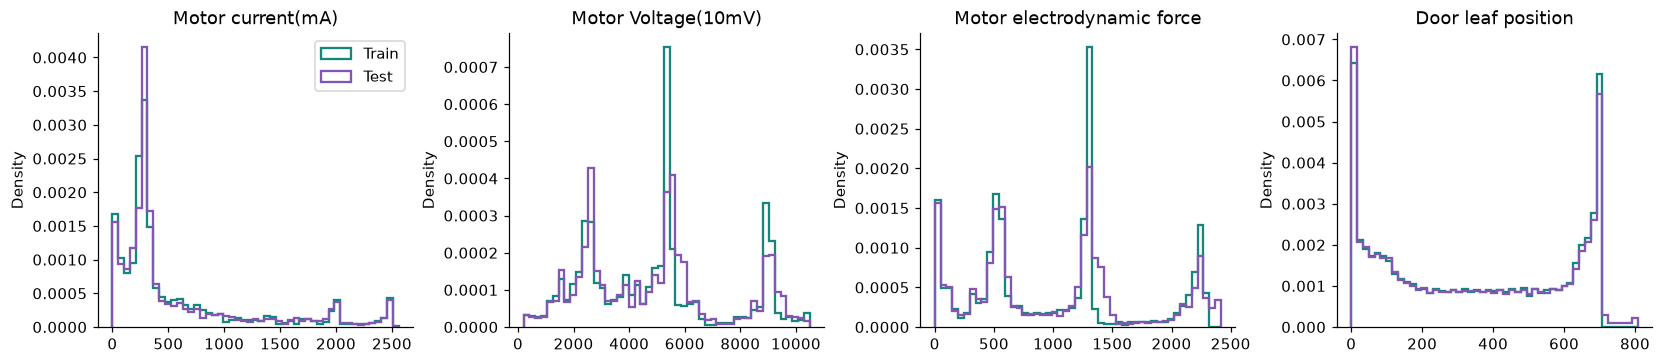

In [11]:
SIGNALS = ['Motor current(mA)', 'Motor Voltage(10mV)', 'Motor electrodynamic force', 'Door leaf position']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, column in zip(axes, SIGNALS):
    bins = np.linspace(min(f[column].min() for f in raw.values()), max(f[column].max() for f in raw.values()), 50)
    for split, color in [('Train', COLORS['Normal']), ('Test', COLORS['Test'])]:
        ax.hist(raw[split][column], bins=bins, density=True, histtype='step', linewidth=1.5, color=color, label=split)
    ax.set(title=column, ylabel='Density')
axes[0].legend()
plt.show()

<blockquote><h3 id="3-7"><b>3.7 Sample Rows</b></h3></blockquote>

In the cell below, the first rows of the parsed Train stream are displayed to confirm the column
values and the parsed timestamp.

In [12]:
display(streams['Train'].head(6))

,time,Datetime,Motor current(mA),Motor Voltage(10mV),Motor electrodynamic force,Door opening time(.1s),Door closing time(.1s),Close command,Open command,DCSR,DCSL,DLSR,DLSL,Door Opened,Door Locked,Door is opening,Door is closing,Door leaf position
0,2023-07-05 00:00:00.000,2023-7-5-0-0-0-0,115,400,53,24,35,1,0,0,0,0,0,0,0,0,1,700
1,2023-07-05 00:00:00.020,2023-7-5-0-0-0-20,132,600,93,24,35,1,0,0,0,0,0,0,0,0,1,700
2,2023-07-05 00:00:00.040,2023-7-5-0-0-0-40,176,700,108,24,35,1,0,0,0,0,0,0,0,0,1,700
3,2023-07-05 00:00:00.060,2023-7-5-0-0-0-60,317,1000,114,24,35,1,0,0,0,0,0,0,0,0,1,699
4,2023-07-05 00:00:00.080,2023-7-5-0-0-0-80,503,1500,150,24,35,1,0,0,0,0,0,0,0,0,1,699
5,2023-07-05 00:00:00.100,2023-7-5-0-0-0-100,667,2000,196,24,35,1,0,0,0,0,0,0,0,0,1,698


<blockquote><h3 id="3-8"><b>3.8 Stream Excerpt</b></h3></blockquote>

In the cell below, the first two minutes of the Train stream are plotted. Each dense run of samples is
one movement, and the empty stretches are the logging pauses between movements.

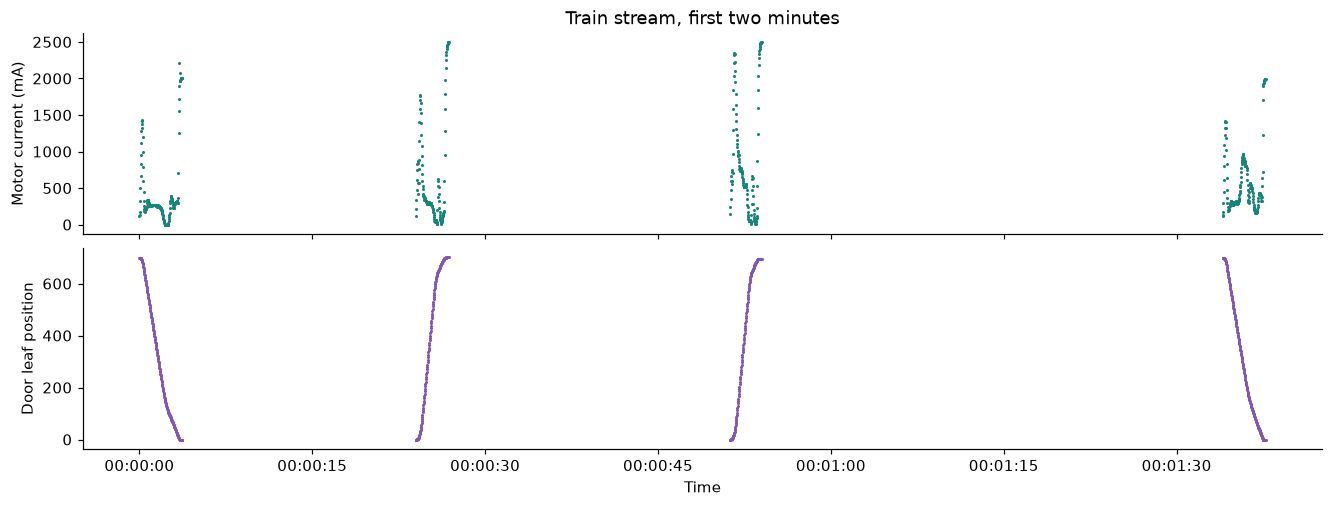

In [13]:
start = streams['Train']['time'].iloc[0]
excerpt = streams['Train'][streams['Train']['time'] < start + pd.Timedelta('120s')]
fig, axes = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
axes[0].plot(excerpt['time'], excerpt['Motor current(mA)'], '.', ms=2, color=COLORS['Normal'])
axes[1].plot(excerpt['time'], excerpt['Door leaf position'], '.', ms=2, color=COLORS['Test'])
axes[0].set(ylabel='Motor current (mA)', title='Train stream, first two minutes')
axes[1].set(ylabel='Door leaf position', xlabel='Time')
plt.show()

<blockquote><h3 id="3-9"><b>3.9 Answer File Validation</b></h3></blockquote>

In the cell below, the answer file is checked for unique identifiers, missing cells, ordered and
non-overlapping bounds, and agreement between each stated row count and the row count implied by its
bounds at 20 ms per row. The operation and status counts are also tabulated.

In [14]:
answers['start'] = parse_time(answers['start_time'])
answers['end'] = parse_time(answers['end_time'])
implied_rows = ((answers['end'] - answers['start']) / SAMPLE_PERIOD).round().astype(int) + 1
answer_checks = pd.Series({
    'segments': len(answers),
    'unique segment identifiers': answers['segment_id'].is_unique,
    'missing cells': int(answers.isna().sum().sum()),
    'start before end': bool((answers['start'] < answers['end']).all()),
    'chronological order': answers['start'].is_monotonic_increasing,
    'no overlaps': bool((answers['start'].iloc[1:].to_numpy() > answers['end'].iloc[:-1].to_numpy()).all()),
    'row counts match bounds': bool(implied_rows.eq(answers['n_rows']).all()),
}, name='value')
display(answer_checks.to_frame())
display(pd.crosstab(answers['operation'], answers['status'], margins=True))

,value
segments,110
unique segment identifiers,True
missing cells,0
start before end,True
chronological order,True
no overlaps,True
row counts match bounds,True


status,Abnormal resistance,Normal,All
operation,,,
Close,15,40,55
Open,15,40,55
All,30,80,110


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-4" style="color: black;"><b>Section 4: Movement Segmentation</b></h2>
</div>

This section splits both streams into movements at logging pauses, verifies the Train movements
against the answer file, assigns each movement its operation, and assembles one table with a row per
movement.

<blockquote><h3 id="4-1"><b>4.1 Gap-Based Segmentation</b></h3></blockquote>

In the cell below, a new movement starts wherever the step to the previous sample exceeds the 20 ms
sampling period. Movements are numbered from zero in stream order, which matches the cycle numbering
used in the Door exploratory data analysis.

In [15]:
def segment(stream):
    """Number contiguous runs of samples; a new run starts where the step exceeds 20 ms."""
    return (stream['time'].diff() > SAMPLE_PERIOD).cumsum().rename('movement')


for stream in streams.values():
    stream['movement'] = segment(stream)
    stream['row_in_movement'] = stream.groupby('movement').cumcount()
display(pd.Series({split: stream['movement'].nunique() for split, stream in streams.items()},
                  name='movements').to_frame())

,movements
Train,110
Test,38


<blockquote><h3 id="4-2"><b>4.2 Agreement with the Answer Segments</b></h3></blockquote>

In the cell below, the first and last timestamps of each Train movement are matched against the
answer bounds. An exact match of both bounds gives an intersection over union of 1, so every matched
movement would score perfectly on segmentation.

In [16]:
bounds = streams['Train'].groupby('movement').agg(start=('time', 'first'), end=('time', 'last'),
                                                  n_rows=('time', 'size'))
matched = bounds.reset_index().merge(answers, on=['start', 'end'], how='outer',
                                     suffixes=('', '_answer'), indicator=True)
agreement = pd.Series({
    'answer segments': len(answers),
    'gap-delimited Train movements': len(bounds),
    'exact start and end matches': int(matched['_merge'].eq('both').sum()),
    'movements without an answer': int(matched['_merge'].eq('left_only').sum()),
    'answers without a movement': int(matched['_merge'].eq('right_only').sum()),
    'row-count disagreements': int(matched['n_rows'].ne(matched['n_rows_answer']).sum()),
}, name='count')
display(agreement.to_frame())

,count
answer segments,110
gap-delimited Train movements,110
exact start and end matches,110
movements without an answer,0
answers without a movement,0
row-count disagreements,0


<blockquote><h3 id="4-3"><b>4.3 Operation Assignment</b></h3></blockquote>

In the cell below, a movement is labelled `Open` when the open command is active at any of its rows
and `Close` otherwise. The rule is compared with the operations stated in the answer file, and each
Close movement is checked to carry an active close command.

In [17]:
def operation_of(stream):
    """Open where the open command is active at any row of the movement, otherwise Close."""
    return stream.groupby('movement')['Open command'].max().map({1: 'Open', 0: 'Close'}).rename('operation')


rule = matched.set_index('movement')[['operation']].join(operation_of(streams['Train']).rename('open-command rule'))
display(pd.crosstab(rule['operation'], rule['open-command rule'], rownames=['answer file']))
for split, stream in streams.items():
    ops = operation_of(stream)
    close_cmd = stream.groupby('movement')['Close command'].max()
    print(f'{split}: Close movements without a close command:', int((ops.eq('Close') & close_cmd.eq(0)).sum()))

open-command rule,Close,Open
answer file,,
Close,55,0
Open,0,55


Train: Close movements without a close command: 0
Test: Close movements without a close command: 0


<blockquote><h3 id="4-4"><b>4.4 Movement Table Assembly</b></h3></blockquote>

In the cell below, one row per movement is built for both streams, with parsed and native-format
bounds, row count, duration, operation and door-position extremes. Train movements take their
identifier and status from the answer file; Test movements receive identifiers in the same style,
numbered from 1. The binary `label` is 1 for `Abnormal resistance`.

In [18]:
def movement_table(stream, split):
    """One row per movement: bounds, size, duration, operation and door-position extremes."""
    g = stream.groupby('movement')
    table = pd.DataFrame({
        'dataset': split,
        'start': g['time'].first(), 'end': g['time'].last(),
        'start_time': g['Datetime'].first(), 'end_time': g['Datetime'].last(),
        'n_rows': g.size(),
        'first_position': g['Door leaf position'].first(),
        'last_position': g['Door leaf position'].last(),
        'max_position': g['Door leaf position'].max(),
    })
    table['duration_s'] = (table['end'] - table['start']).dt.total_seconds()
    return table.join(operation_of(stream)).reset_index()


train_movements = movement_table(streams['Train'], 'Train').merge(
    answers[['start', 'end', 'segment_id', 'status']], on=['start', 'end'], how='left', validate='one_to_one')
test_movements = movement_table(streams['Test'], 'Test')
test_movements['segment_id'] = [f'test_seg_{i + 1:03d}' for i in test_movements['movement']]
test_movements['status'] = pd.NA

movements = pd.concat([train_movements, test_movements], ignore_index=True).rename(columns={'segment_id': 'movement_id'})
movements['status'] = movements['status'].astype('string')
movements['label'] = movements['status'].map({'Normal': 0, 'Abnormal resistance': 1}).astype('Int64')
leading = ['movement_id', 'dataset', 'movement', 'operation', 'status', 'label']
movements = movements[leading + [c for c in movements.columns if c not in leading]]
assert movements['movement_id'].is_unique
display(movements.head())

,movement_id,dataset,movement,operation,status,label,start,end,start_time,end_time,n_rows,first_position,last_position,max_position,duration_s
0,train_seg_001,Train,0,Close,Normal,0,2023-07-05 00:00:00.000,2023-07-05 00:00:03.700,2023-7-5-0-0-0-0,2023-7-5-0-0-3-700,186,700,0,700,3.70
1,train_seg_002,Train,1,Open,Normal,0,2023-07-05 00:00:23.999,2023-07-05 00:00:26.839,2023-7-5-0-0-23-999,2023-7-5-0-0-26-839,143,0,701,701,2.84
2,train_seg_003,Train,2,Open,Abnormal resistance,1,2023-07-05 00:00:51.266,2023-07-05 00:00:53.986,2023-7-5-0-0-51-266,2023-7-5-0-0-53-986,137,0,695,695,2.72
3,train_seg_004,Train,3,Close,Abnormal resistance,1,2023-07-05 00:01:33.989,2023-07-05 00:01:37.709,2023-7-5-0-1-33-989,2023-7-5-0-1-37-709,187,700,0,700,3.72
4,train_seg_005,Train,4,Close,Abnormal resistance,1,2023-07-05 00:02:24.608,2023-07-05 00:02:28.308,2023-7-5-0-2-24-608,2023-7-5-0-2-28-308,186,700,1,700,3.70


<blockquote><h3 id="4-5"><b>4.5 Movement Counts and Lengths</b></h3></blockquote>

In the cell below, movements are counted by dataset, operation and status, and their row counts are
summarised for each dataset and operation.

In [19]:
display(pd.crosstab([movements['dataset'], movements['operation']], movements['status'].fillna('Unlabelled'), margins=True))
display(movements.groupby(['dataset', 'operation'])['n_rows'].describe()[['count', 'min', '50%', 'max']])

status             Abnormal resistance  Normal  Unlabelled  All
dataset operation                                              
Test    Close                        0       0          20   20
        Open                         0       0          18   18
Train   Close                       15      40           0   55
        Open                        15      40           0   55
All                                 30      80          38  148

count    min    50%    max
dataset operation                            
Test    Close       20.0  172.0  186.5  190.0
        Open        18.0  135.0  142.0  185.0
Train   Close       55.0  178.0  186.0  190.0
        Open        55.0  137.0  142.0  147.0

<blockquote><h3 id="4-6"><b>4.6 Movement Length Distributions</b></h3></blockquote>

In the cell below, the row count of every movement is plotted by operation for Train Normal, Train
Abnormal resistance and Test movements, with a small horizontal jitter to separate points.

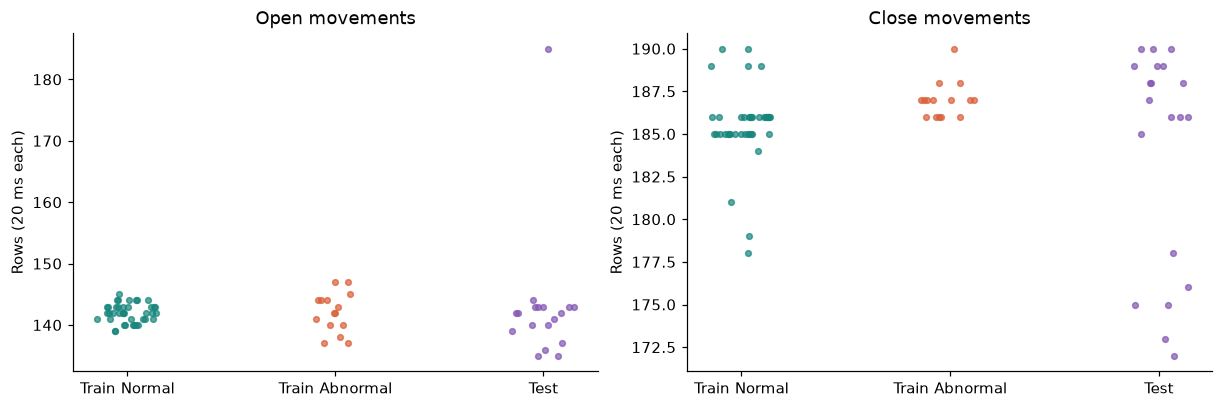

In [20]:
rng = np.random.default_rng(SEED)
group = movements['status'].fillna('Test')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, op in zip(axes, ['Open', 'Close']):
    for i, name in enumerate(['Normal', 'Abnormal resistance', 'Test']):
        values = movements.loc[movements['operation'].eq(op) & group.eq(name), 'n_rows']
        ax.scatter(i + rng.uniform(-0.15, 0.15, len(values)), values, s=14, alpha=0.7, color=COLORS[name])
    ax.set(xticks=range(3), xticklabels=['Train Normal', 'Train Abnormal', 'Test'],
           ylabel='Rows (20 ms each)', title=f'{op} movements')
plt.show()

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-5" style="color: black;"><b>Section 5: Quality Flags and Cleaning</b></h2>
</div>

This section derives per-movement quality flags instead of deleting data: controller timing values,
disagreement between paired switches, constant columns, and Test movements outside the Train
envelope. Each flag is stored with the movement so that later models can use or exclude it.

<blockquote><h3 id="5-1"><b>5.1 Controller Timing Values</b></h3></blockquote>

The controller reports an opening time and a closing time in tenths of a second. In the cell below,
each movement takes the value of its own operation's timing column at its last row, together with
whether that value changed during the movement and how many rows show a zero in either timing column.
A zero is treated as missing because no movement completes in zero time.

In [21]:
TIMING = {'Open': 'Door opening time(.1s)', 'Close': 'Door closing time(.1s)'}


def controller_timing(stream):
    """Per movement: own timing value at the last row, whether it changed, and rows with a zero timing value."""
    operations = operation_of(stream)
    rows = {}
    for movement, g in stream.groupby('movement'):
        values = g[TIMING[operations[movement]]].to_numpy()
        rows[movement] = {'controller_time_raw': int(values[-1]),
                          'controller_time_updated': bool((np.diff(values) != 0).any()),
                          'timing_zero_rows': int((g[list(TIMING.values())] == 0).any(axis=1).sum())}
    return pd.DataFrame.from_dict(rows, orient='index')


timing = pd.concat({split: controller_timing(stream) for split, stream in streams.items()},
                   names=['dataset', 'movement']).reset_index()
movements = movements.merge(timing, on=['dataset', 'movement'], how='left', validate='one_to_one')
movements['controller_time_s'] = movements['controller_time_raw'].where(movements['controller_time_raw'] > 0) / 10
display(movements.groupby(['dataset', 'operation'])['controller_time_raw'].agg(['min', 'median', 'max']))
display(movements.loc[movements['timing_zero_rows'] > 0,
                      ['movement_id', 'operation', 'n_rows', 'controller_time_raw', 'timing_zero_rows']])

min  median  max
dataset operation                  
Test    Close       32    35.0   35
        Open        22    23.5   32
Train   Close       33    35.0   35
        Open        23    24.0   25

,movement_id,operation,n_rows,controller_time_raw,timing_zero_rows
134,test_seg_025,Close,173,32,161
142,test_seg_033,Open,185,32,185


<blockquote><h3 id="5-2"><b>5.2 Switch Pair Agreement</b></h3></blockquote>

The right and left door-closed switches (`DCSR`, `DCSL`) and door-locked switches (`DLSR`, `DLSL`)
should agree. In the cell below, the rows in which each pair disagrees are counted per movement, and
the movements with any disagreement are counted per dataset.

In [22]:
SWITCH_PAIRS = {'closed_switch_disagreement_rows': ('DCSR', 'DCSL'),
                'locked_switch_disagreement_rows': ('DLSR', 'DLSL')}
switches = pd.concat({split: pd.DataFrame({name: stream[a].ne(stream[b]).groupby(stream['movement']).sum()
                                           for name, (a, b) in SWITCH_PAIRS.items()})
                      for split, stream in streams.items()}, names=['dataset', 'movement']).reset_index()
movements = movements.merge(switches, on=['dataset', 'movement'], how='left', validate='one_to_one')
display(movements.groupby('dataset')[list(SWITCH_PAIRS)].agg(lambda s: int((s > 0).sum()))
        .rename(columns=lambda c: c.replace('_rows', '_movements')))

,closed_switch_disagreement_movements,locked_switch_disagreement_movements
dataset,,
Test,6,12
Train,19,12


<blockquote><h3 id="5-3"><b>5.3 Constant Columns and Column Usage</b></h3></blockquote>

In the cell below, columns that hold a single value across both streams are identified, and the use
of every column in the prepared outputs is recorded. Constant columns carry no information and are
excluded from all representations.

In [23]:
combined = pd.concat(raw.values(), ignore_index=True)
constant = [c for c in combined.columns if combined[c].nunique() == 1]
USAGE = {
    'timestamp': 'segmentation and native-format movement bounds',
    'analogue signal': 'profiles, phase statistics and position-binned current',
    'controller timing': 'cleaned per-movement value; zero treated as missing',
    'command': 'operation assignment',
    'switch': 'quality flags only',
    'status flag': 'kept in the sample table; not summarised',
}
usage = pd.DataFrame({'role': pd.Series(COLUMN_ROLES)})
usage['use'] = usage['role'].map(USAGE)
usage.loc[constant, 'use'] = 'excluded: constant in Train and Test'
display(usage)

,role,use
Datetime,timestamp,segmentation and native-format movement bounds
Motor current(mA),analogue signal,"profiles, phase statistics and position-binned..."
Motor Voltage(10mV),analogue signal,"profiles, phase statistics and position-binned..."
Motor electrodynamic force,analogue signal,"profiles, phase statistics and position-binned..."
Door leaf position,analogue signal,"profiles, phase statistics and position-binned..."
Door opening time(.1s),controller timing,cleaned per-movement value; zero treated as mi...
Door closing time(.1s),controller timing,cleaned per-movement value; zero treated as mi...
Close command,command,operation assignment
Open command,command,operation assignment
DCSR,switch,quality flags only


<blockquote><h3 id="5-4"><b>5.4 Out-of-Envelope Test Movements</b></h3></blockquote>

In the cell below, the Train range of row counts and maximum door position is computed for each
operation, and Test movements falling outside either range are flagged. Such movements lie outside the
conditions represented by the labelled data.

In [24]:
envelope = (movements[movements['dataset'].eq('Train')].groupby('operation')
            .agg(n_rows_min=('n_rows', 'min'), n_rows_max=('n_rows', 'max'),
                 max_position_min=('max_position', 'min'), max_position_max=('max_position', 'max')))
limits = movements[['operation']].join(envelope, on='operation')
movements['length_outside_train'] = ~movements['n_rows'].between(limits['n_rows_min'], limits['n_rows_max'])
movements['position_outside_train'] = ~movements['max_position'].between(limits['max_position_min'],
                                                                         limits['max_position_max'])
display(envelope)
display(movements.loc[movements['length_outside_train'] | movements['position_outside_train'],
                      ['movement_id', 'operation', 'n_rows', 'max_position', 'controller_time_raw']])

,n_rows_min,n_rows_max,max_position_min,max_position_max
operation,,,,
Close,178,190,700,700
Open,137,147,695,705


,movement_id,operation,n_rows,max_position,controller_time_raw
114,test_seg_005,Close,176,700,33
117,test_seg_008,Close,172,700,32
119,test_seg_010,Open,137,706,23
121,test_seg_012,Open,136,715,22
126,test_seg_017,Close,175,700,32
134,test_seg_025,Close,173,700,32
137,test_seg_028,Open,135,707,22
138,test_seg_029,Open,140,693,23
142,test_seg_033,Open,185,807,32
144,test_seg_035,Open,135,703,22


<blockquote><h3 id="5-5"><b>5.5 Quality Flag Summary</b></h3></blockquote>

In the cell below, the quality flags are converted to booleans and counted per dataset. `review_flag`
marks movements with missing or zero timing values or outside the Train envelope. Switch
disagreements remain separate informational flags because they describe sensor agreement rather than
the movement itself.

In [25]:
movements['timing_missing'] = movements['controller_time_s'].isna()
movements['timing_zero_values'] = movements['timing_zero_rows'] > 0
movements['closed_switch_disagreement'] = movements['closed_switch_disagreement_rows'] > 0
movements['locked_switch_disagreement'] = movements['locked_switch_disagreement_rows'] > 0
REVIEW_FLAGS = ['timing_missing', 'timing_zero_values', 'length_outside_train', 'position_outside_train']
SENSOR_FLAGS = ['closed_switch_disagreement', 'locked_switch_disagreement']
movements['review_flag'] = movements[REVIEW_FLAGS].any(axis=1)
display(movements.groupby('dataset')[REVIEW_FLAGS + ['review_flag'] + SENSOR_FLAGS].sum().T)

dataset,Test,Train
timing_missing,0,0
timing_zero_values,2,0
length_outside_train,9,0
position_outside_train,5,0
review_flag,11,0
closed_switch_disagreement,6,19
locked_switch_disagreement,12,12


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-6" style="color: black;"><b>Section 6: Representations and Features</b></h2>
</div>

This section builds the representations used by the planned models: a sample-level table with
relative time and door travel, fixed-length profiles, the baseline window current, phase statistics,
and current binned by door travel. All representations are computed per movement without labels, so
they can be precomputed once outside the validation folds.

<blockquote><h3 id="6-1"><b>6.1 Sample-Level Movement Table</b></h3></blockquote>

In the cell below, every sample receives its movement identifier and operation, its relative time
from 0 at the first row to 1 at the last row, and its door travel as a fraction of full travel. Full
travel is the median final position of Train Open movements. Travel runs from 0 to 1 in both
directions, so Close movements use one minus the position fraction.

In [26]:
FULL_TRAVEL = float(movements.loc[movements['dataset'].eq('Train') & movements['operation'].eq('Open'),
                                  'last_position'].median())
keys = movements.set_index(['dataset', 'movement'])[['movement_id', 'operation', 'n_rows']]
samples = pd.concat([stream.assign(dataset=split) for split, stream in streams.items()], ignore_index=True)
samples = samples.join(keys, on=['dataset', 'movement'])
samples['relative_time'] = samples['row_in_movement'] / (samples['n_rows'] - 1)
fraction = samples['Door leaf position'] / FULL_TRAVEL
samples['travel'] = np.where(samples['operation'].eq('Open'), fraction, 1 - fraction)
print('Full travel (position units):', FULL_TRAVEL)
display(samples[['dataset', 'movement_id', 'time', 'operation', 'relative_time', 'travel',
                 'Motor current(mA)', 'Door leaf position']].head())

Full travel (position units): 700.0


,dataset,movement_id,time,operation,relative_time,travel,Motor current(mA),Door leaf position
0,Train,train_seg_001,2023-07-05 00:00:00.000,Close,0.000000,0.000000,115,700
1,Train,train_seg_001,2023-07-05 00:00:00.020,Close,0.005405,0.000000,132,700
2,Train,train_seg_001,2023-07-05 00:00:00.040,Close,0.010811,0.000000,176,700
3,Train,train_seg_001,2023-07-05 00:00:00.060,Close,0.016216,0.001429,317,699
4,Train,train_seg_001,2023-07-05 00:00:00.080,Close,0.021622,0.001429,503,699


<blockquote><h3 id="6-2"><b>6.2 Fixed-Length Profiles</b></h3></blockquote>

In the cell below, the current, voltage, back electromotive force and position of every movement are
linearly interpolated onto 100 equally spaced points of relative time. This is the same resampling
used by the backend baseline, and it gives every movement the same length for profile-based models.

In [27]:
PROFILE_POINTS = 100
PROFILE_SIGNALS = {'current': 'Motor current(mA)', 'voltage': 'Motor Voltage(10mV)',
                   'back_emf': 'Motor electrodynamic force', 'position': 'Door leaf position'}


def resample(values, n=PROFILE_POINTS):
    """Interpolate a movement onto `n` equally spaced points of relative time."""
    return np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(values)), values.astype(float))


profile_rows = {movement_id: np.concatenate([resample(g[col].to_numpy()) for col in PROFILE_SIGNALS.values()])
                for movement_id, g in samples.groupby('movement_id', sort=False)}
profile_columns = [f'{name}_{k:02d}' for name in PROFILE_SIGNALS for k in range(PROFILE_POINTS)]
profiles = pd.DataFrame.from_dict(profile_rows, orient='index', columns=profile_columns).rename_axis('movement_id')
profiles = profiles.reindex(movements['movement_id'])
print('Profile table shape:', profiles.shape)
display(profiles.iloc[:3, :6])

Profile table shape: (148, 400)


,current_00,current_01,current_02,current_03,current_04,current_05
movement_id,,,,,,
train_seg_001,115.0,170.222222,454.151515,763.363636,1033.484848,1316.252525
train_seg_002,112.0,267.121212,449.666667,653.121212,808.252525,866.565657
train_seg_003,141.0,276.858586,441.181818,604.757576,693.171717,746.848485


<blockquote><h3 id="6-3"><b>6.3 Baseline Window Current</b></h3></blockquote>

The current Door baseline labels a movement by its mean resampled current over the part of the stroke
where resistance shows: points 20 to 39 for Open and 35 to 64 for Close. In the cell below, this
feature is reproduced from the profiles and summarised by dataset, operation and status.

In [28]:
WINDOWS = {'Open': (20, 40), 'Close': (35, 65)}  # profile points, [start, end), as in the backend baseline


def window_current(profiles, operations):
    """Mean resampled current over each movement's operation window."""
    return pd.Series({mid: profiles.loc[mid, [f'current_{k:02d}' for k in range(*WINDOWS[op])]].mean()
                      for mid, op in operations.items()}, name='window_current')


movements = movements.join(window_current(profiles, movements.set_index('movement_id')['operation']), on='movement_id')
display(movements.groupby(['dataset', 'operation', movements['status'].fillna('Unlabelled')])['window_current']
        .agg(['count', 'min', 'median', 'max']).round(1))

count    min  median     max
dataset operation status                                           
Test    Close     Unlabelled              20  157.2   172.6   734.6
        Open      Unlabelled              18  259.7   358.5  1150.4
Train   Close     Abnormal resistance     15  320.6   616.5   843.7
                  Normal                  40  157.0   167.0   177.3
        Open      Abnormal resistance     15  576.3   780.5  1133.2
                  Normal                  40  338.7   348.0   359.0

<blockquote><h3 id="6-4"><b>6.4 Phase Statistics</b></h3></blockquote>

In the cell below, each movement is divided by relative time into a start phase (first 20%), a middle
phase (20% to 80%) and an end phase (last 20%). Mean and maximum current are computed per phase,
together with whole-movement peak current, mean current, charge (current integrated over time), mean
voltage, mean back electromotive force and the share of rows with zero current.

In [29]:
def phase_statistics(samples):
    """Per movement: current by phase plus whole-movement electrical summaries."""
    rt = samples['relative_time']
    phase = pd.Series(np.select([rt < 0.2, rt < 0.8], ['start', 'middle'], 'end'), index=samples.index)
    g = samples.groupby('movement_id', sort=False)
    current = g['Motor current(mA)']
    table = pd.DataFrame({
        'peak_current': current.max(),
        'mean_current': current.mean(),
        'charge_mAs': current.sum() * SAMPLE_PERIOD.total_seconds(),
        'mean_voltage': g['Motor Voltage(10mV)'].mean(),
        'mean_back_emf': g['Motor electrodynamic force'].mean(),
        'zero_current_share': samples['Motor current(mA)'].eq(0).groupby(samples['movement_id']).mean(),
    })
    by_phase = samples.groupby(['movement_id', phase])['Motor current(mA)'].agg(['mean', 'max']).unstack()
    by_phase.columns = [f'{p}_{stat}_current' for stat, p in by_phase.columns]
    return table.join(by_phase)


phase_table = phase_statistics(samples)
movements = movements.join(phase_table, on='movement_id')
display(phase_table.head())

,peak_current,mean_current,charge_mAs,mean_voltage,mean_back_emf,zero_current_share,end_mean_current,middle_mean_current,start_mean_current,end_max_current,middle_max_current,start_max_current
movement_id,,,,,,,,,,,,
test_seg_001,2084,463.978836,1753.84,4149.735450,878.243386,0.068783,1127.105263,211.477876,551.710526,2084,397,1461
test_seg_002,2102,463.116402,1750.58,4142.857143,877.624339,0.063492,1126.368421,211.336283,548.578947,2102,406,1458
test_seg_003,2501,660.248227,1861.90,5624.822695,1199.269504,0.000000,1487.310345,257.607143,1011.571429,2501,703,1861
test_seg_004,2501,681.878571,1909.26,5716.428571,1212.000000,0.028571,1611.178571,251.690476,1043.142857,2501,723,1966
test_seg_005,2137,462.250000,1627.12,4388.636364,948.738636,0.005682,1021.944444,228.847619,586.771429,2137,409,1587


<blockquote><h3 id="6-5"><b>6.5 Position-Binned Current</b></h3></blockquote>

In the cell below, door travel is divided into 20 bins of 5% each, and the mean current in each bin is
computed per movement. Binning by position aligns movements by where the door is rather than by when,
which separates resistance at a given point of the track from differences in speed. Travel beyond full
travel falls in the last bin; the overshoot itself is already flagged in Section 5.

In [30]:
TRAVEL_BINS = 20
travel_bin = (samples['travel'].clip(lower=0) * TRAVEL_BINS).astype(int).clip(upper=TRAVEL_BINS - 1)
position_bins = (samples.groupby(['movement_id', travel_bin.rename('bin')])['Motor current(mA)'].mean()
                 .unstack('bin').reindex(index=movements['movement_id'], columns=range(TRAVEL_BINS)))
position_bins.columns = [f'travel_{5 * b:02d}_{5 * b + 5:03d}' for b in range(TRAVEL_BINS)]
movements['empty_travel_bins'] = position_bins.isna().sum(axis=1).to_numpy()
display(position_bins.iloc[:3, :6])
display(movements.groupby(['dataset', 'operation'])['empty_travel_bins'].agg(['min', 'max', 'sum']))

,travel_00_005,travel_05_010,travel_10_015,travel_15_020,travel_20_025,travel_25_030
movement_id,,,,,,
train_seg_001,859.764706,312.857143,211.166667,288.857143,304.5,254.00
train_seg_002,880.050000,1378.000000,758.500000,454.750000,369.0,353.50
train_seg_003,1136.400000,1940.600000,1324.000000,1031.500000,963.0,828.75


min  max  sum
dataset operation               
Test    Close        0    0    0
        Open         0    0    0
Train   Close        0    0    0
        Open         0    0    0

<blockquote><h3 id="6-6"><b>6.6 Feature Integrity and Coverage</b></h3></blockquote>

In the cell below, the scalar features are checked for missing values, and for each operation the
number of Test movements whose value falls outside the Train range is counted. Features with many
out-of-range Test values are more likely to be affected by the difference between the streams.

In [31]:
SCALAR_FEATURES = ['n_rows', 'duration_s', 'controller_time_s', 'window_current', 'peak_current', 'mean_current',
                   'charge_mAs', 'mean_voltage', 'mean_back_emf', 'zero_current_share',
                   'start_mean_current', 'middle_mean_current', 'end_mean_current',
                   'start_max_current', 'middle_max_current', 'end_max_current']
coverage = {}
for op in ['Open', 'Close']:
    train = movements[movements['dataset'].eq('Train') & movements['operation'].eq(op)]
    test = movements[movements['dataset'].eq('Test') & movements['operation'].eq(op)]
    coverage[f'{op}: Test outside Train range'] = {
        f: int((~test[f].between(train[f].min(), train[f].max()) & test[f].notna()).sum()) for f in SCALAR_FEATURES}
coverage = pd.DataFrame(coverage)
coverage.insert(0, 'missing values', movements[SCALAR_FEATURES].isna().sum())
display(coverage)

,missing values,Open: Test outside Train range,Close: Test outside Train range
n_rows,0,4,5
duration_s,0,4,5
controller_time_s,0,4,4
window_current,0,2,0
peak_current,0,0,0
mean_current,0,1,0
charge_mAs,0,0,0
mean_voltage,0,1,0
mean_back_emf,0,5,7
zero_current_share,0,2,0


<blockquote><h3 id="6-7"><b>6.7 Current Profile Overview</b></h3></blockquote>

In the cell below, the median current profile is plotted for Train Normal, Train Abnormal resistance
and Test movements of each operation. The shaded band marks the baseline window.

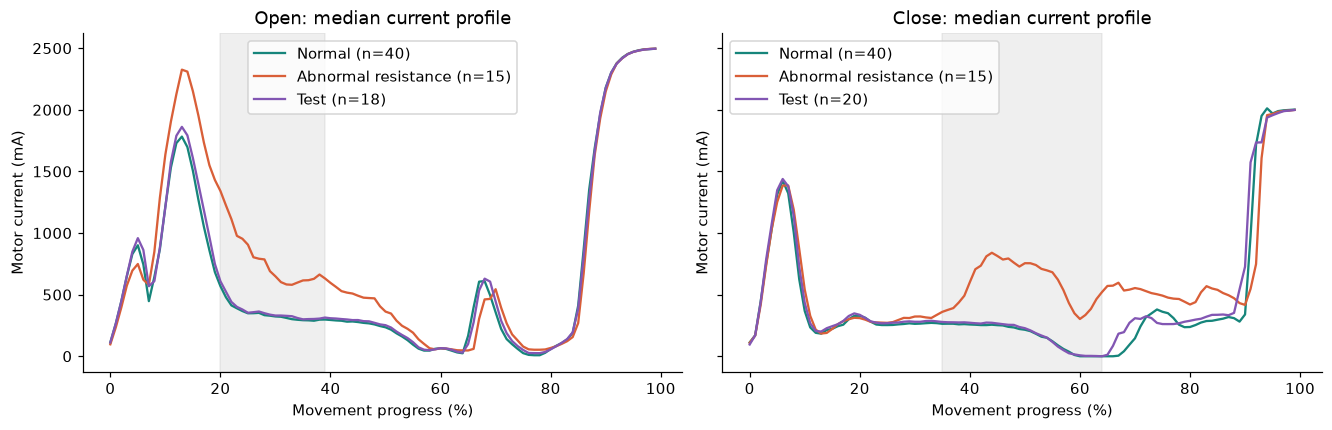

In [32]:
current_columns = [f'current_{k:02d}' for k in range(PROFILE_POINTS)]
meta = movements.set_index('movement_id')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, op in zip(axes, ['Open', 'Close']):
    for name in ['Normal', 'Abnormal resistance', 'Test']:
        ids = meta.index[meta['operation'].eq(op) & meta['status'].fillna('Test').eq(name)]
        ax.plot(range(PROFILE_POINTS), profiles.loc[ids, current_columns].median(), color=COLORS[name],
                label=f'{name} (n={len(ids)})')
    ax.axvspan(WINDOWS[op][0], WINDOWS[op][1] - 1, color='grey', alpha=0.12)
    ax.set(title=f'{op}: median current profile', xlabel='Movement progress (%)', ylabel='Motor current (mA)')
    ax.legend()
plt.show()

<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-7" style="color: black;"><b>Section 7: Validation Folds</b></h2>
</div>

This section assigns fixed validation folds to the labelled Train movements so that every model is
compared on the same splits. Whole movements are the unit of assignment, so no movement is split
across training and validation.

<blockquote><h3 id="7-1"><b>7.1 Stratified Folds</b></h3></blockquote>

In the cell below, the 110 Train movements are divided into five folds stratified by operation and
status with the fixed seed. Each fold therefore holds a similar share of Abnormal resistance movements
for both operations.

In [33]:
train_index = movements.index[movements['dataset'].eq('Train')]
strata = (movements.loc[train_index, 'operation'] + ' | ' + movements.loc[train_index, 'status']).rename('operation | status')
movements['fold'] = pd.Series(pd.NA, index=movements.index, dtype='Int64')
splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for fold, (_, valid) in enumerate(splitter.split(np.zeros(len(train_index)), strata)):
    movements.loc[train_index[valid], 'fold'] = fold
display(pd.crosstab(movements.loc[train_index, 'fold'], strata, margins=True))

operation | status,Close | Abnormal resistance,Close | Normal,Open | Abnormal resistance,Open | Normal,All
fold,,,,,
0,3,8,3,8,22
1,3,8,3,8,22
2,3,8,3,8,22
3,3,8,3,8,22
4,3,8,3,8,22
All,15,40,15,40,110


<blockquote><h3 id="7-2"><b>7.2 Time-Ordered Blocks</b></h3></blockquote>

In the cell below, the Train movements are also divided into five contiguous blocks in recording
order. Blocks support a sensitivity check for drift over time, which random folds cannot reveal.

In [34]:
order = movements.loc[train_index].sort_values('start').index
movements['time_block'] = pd.Series(pd.NA, index=movements.index, dtype='Int64')
movements.loc[order, 'time_block'] = np.arange(len(order)) * 5 // len(order)
display(pd.crosstab(movements.loc[train_index, 'time_block'], strata, margins=True))

operation | status,Close | Abnormal resistance,Close | Normal,Open | Abnormal resistance,Open | Normal,All
time_block,,,,,
0,3,6,4,9,22
1,2,6,1,13,22
2,3,11,4,4,22
3,4,9,2,7,22
4,3,8,4,7,22
All,15,40,15,40,110


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-8" style="color: black;"><b>Section 8: Export</b></h2>
</div>

This section writes the prepared tables to Parquet, records a manifest of settings and sources, and
verifies that every file reads back identically.

<blockquote><h3 id="8-1"><b>8.1 Output Tables</b></h3></blockquote>

In the cell below, four tables are written: one row per movement with labels, flags, features and
folds; one row per sample with relative time and travel; the fixed-length profiles; and the
position-binned current.

In [35]:
sample_columns = ['dataset', 'movement_id', 'movement', 'row_in_movement', 'time', 'Datetime', 'operation',
                  'relative_time', 'travel'] + [c for c in COLUMN_ROLES if c != 'Datetime']
outputs = {
    'door_movements.parquet': movements,
    'door_samples.parquet': samples[sample_columns],
    'door_profiles.parquet': profiles.reset_index(),
    'door_position_bins.parquet': position_bins.rename_axis('movement_id').reset_index(),
}
for name, frame in outputs.items():
    frame.to_parquet(OUT_DIR / name, index=False)
display(pd.DataFrame([{'file': name, 'rows': len(frame), 'columns': frame.shape[1],
                       'size_MB': round((OUT_DIR / name).stat().st_size / 1e6, 3)} for name, frame in outputs.items()]))

,file,rows,columns,size_MB
0,door_movements.parquet,148,44,0.047
1,door_samples.parquet,24289,25,0.560
2,door_profiles.parquet,148,401,0.540
3,door_position_bins.parquet,148,21,0.029


<blockquote><h3 id="8-2"><b>8.2 Manifest</b></h3></blockquote>

In the cell below, a JSON manifest records the source fingerprints, the preprocessing settings and the
size of each output, so that a later notebook can confirm it is reading the expected preparation.

In [36]:
manifest = {
    'subsystem': 'Door',
    'sources': dict(zip(inventory['file'], inventory['sha256'])),
    'settings': {'seed': SEED, 'sample_period_s': SAMPLE_PERIOD.total_seconds(), 'full_travel': FULL_TRAVEL,
                 'profile_points': PROFILE_POINTS, 'baseline_windows': WINDOWS, 'travel_bins': TRAVEL_BINS,
                 'phases': {'start': [0.0, 0.2], 'middle': [0.2, 0.8], 'end': [0.8, 1.0]},
                 'folds': 'StratifiedKFold(5) by operation and status; time_block = 5 contiguous blocks'},
    'review_flags': REVIEW_FLAGS,
    'sensor_flags': SENSOR_FLAGS,
    'outputs': {name: {'rows': len(frame), 'columns': frame.shape[1]} for name, frame in outputs.items()},
}
(OUT_DIR / 'manifest.json').write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest['settings'], indent=2))

{
  "seed": 2026,
  "sample_period_s": 0.02,
  "full_travel": 700.0,
  "profile_points": 100,
  "baseline_windows": {
    "Open": [
      20,
      40
    ],
    "Close": [
      35,
      65
    ]
  },
  "travel_bins": 20,
  "phases": {
    "start": [
      0.0,
      0.2
    ],
    "middle": [
      0.2,
      0.8
    ],
    "end": [
      0.8,
      1.0
    ]
  },
  "folds": "StratifiedKFold(5) by operation and status; time_block = 5 contiguous blocks"
}


<blockquote><h3 id="8-3"><b>8.3 Export Verification</b></h3></blockquote>

In the cell below, each Parquet file is read back and compared with the table in memory, and the
native-format bounds of the Train movements are compared with the answer file.

In [37]:
for name, frame in outputs.items():
    pd.testing.assert_frame_equal(pd.read_parquet(OUT_DIR / name), frame.reset_index(drop=True))
saved = pd.read_parquet(OUT_DIR / 'door_movements.parquet').query("dataset == 'Train'")
bounds_match = saved.set_index('movement_id')[['start_time', 'end_time']].equals(
    answers.set_index('segment_id')[['start_time', 'end_time']].rename_axis('movement_id'))
print('All outputs read back identically.')
print('Train bounds equal the answer file:', bounds_match)

All outputs read back identically.
Train bounds equal the answer file: True


<hr>

<div style="background-color: #ccccff; padding: 15px; border-radius: 10px;">
<h2 id="section-9" style="color: black;"><b>Section 9: Conclusions</b></h2>
</div>

This section summarises the prepared outputs, the data-quality findings, and their implications for
model training. All statements refer to the executed results above.

<blockquote><h3 id="9-1"><b>9.1 Prepared Outputs</b></h3></blockquote>

- `door_movements.parquet` holds 148 movements (110 Train, 38 Test) in 44 columns: identifiers,
  parsed and native-format bounds, operation, status and binary label, controller timing, quality
  flags, baseline window current, phase statistics, stratified folds and time-ordered blocks.
- `door_samples.parquet` holds all 24,289 samples with movement identifiers, relative time and door
  travel. `door_profiles.parquet` holds 100-point profiles of four signals per movement, and
  `door_position_bins.parquet` holds mean current in 20 travel bins, none of which is empty.
- Every file reads back identically, the native-format Train bounds equal the answer file exactly, and
  `manifest.json` records the source fingerprints and settings.

<blockquote><h3 id="9-2"><b>9.2 Data Quality Findings</b></h3></blockquote>

- Both streams are complete and clean at the row level: no missing cells, duplicate rows or repeated
  timestamps, strictly increasing time, valid binary values, no negative analogue values, and no rows
  with both commands or both motion flags active. Every timestamp survives the parse and format round
  trip unchanged.
- Sampling is regular at 20 ms inside movements. Pauses between movements last 10.2 to 58.8 seconds in
  Train and 11.1 to 55.4 seconds in Test, giving 110 Train and 38 Test movements (18 Open, 20 Close).
- All 110 Train movements match the answer bounds exactly with identical row counts, so gap
  segmentation reproduces every labelled segment. The open-command rule reproduces all 110 answer
  operations.
- `Door Locked` is constant at 0 in both streams and is excluded from all representations.
- Two Test movements contain zero controller timing values: `test_seg_025` (Close, 161 rows) and
  `test_seg_033` (Open, all 185 rows). Their final timing values are non-zero, so no timing value is
  missing at the end of a movement.
- Eleven Test movements and no Train movement carry `review_flag`. Nine fall outside the Train length
  range and five outside the Train range of maximum door position. `test_seg_033` is the most extreme:
  185 rows and a maximum position of 807, against 137 to 147 rows and 695 to 705 for Train Open
  movements.
- The door-closed switches disagree in 19 Train and 6 Test movements, and the door-locked switches in
  12 movements of each stream.

<blockquote><h3 id="9-3"><b>9.3 Implications for Modelling</b></h3></blockquote>

- The baseline window current separates the Train classes without overlap: 338.7 to 359.0 mA for
  Normal Open movements against 576.3 to 1,133.2 mA for Abnormal resistance, and 157.0 to 177.3 mA for
  Normal Close movements against 320.6 to 843.7 mA.
- Features taken from the start of the movement and from back electromotive force have the most Test
  values outside the Train range (for example, start maximum current for 8 Test Close movements and
  mean back electromotive force for 5 Open and 7 Close movements). The window current has 2
  out-of-range Test movements and the middle-phase mean current 1, which supports features taken from
  the middle of the stroke.
- Each of the five stratified folds holds 3 Abnormal resistance and 8 Normal movements per operation.
  The time-ordered blocks are uneven, with one block holding a single Abnormal resistance Open
  movement, so block-based checks will be noisier than fold-based ones.
- The representations do not use labels and can be reused as saved. Thresholds, scalers and feature
  selection still have to be fitted inside each fold, and the eleven flagged Test movements merit
  review alongside their predictions.